# Ejercicios Prácticos: Estadística Inferencial para Administración y Contaduría

Este notebook interactivo ha sido diseñado para estudiantes de Administración y Contaduría. Contiene una serie de ejercicios prácticos utilizando Python para la toma de decisiones basada en datos.

**Temas que abordaremos:**
1. Intervalos de Confianza y Pruebas de Hipótesis (1 y 2 Medias, Proporciones y Varianzas).
2. Análisis de Varianza (ANOVA) y Pruebas Post-Hoc.
3. Regresión Lineal Simple.

Completa las celdas de código indicadas con `TU CÓDIGO AQUÍ` e interpreta los resultados bajo una perspectiva gerencial/contable.


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.stats.weightstats import ztest, ttest_ind
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Configuración de estilo visual
plt.style.use('seaborn-v0_8-whitegrid')

---
## 1. Intervalos de Confianza y Pruebas de Hipótesis


### 1.1. Una Media: Auditoría de Viáticos
**Contexto:** Un equipo de auditoría interna está revisando los reportes de viáticos semanales de los ejecutivos de ventas de una corporación. Se sabe históricamente que el gasto promedio ha sido de $450 USD semanales.
Se tomó una muestra aleatoria de 35 reportes recientes, y se desea comprobar (con un nivel de confianza del 95%) si el gasto de viáticos ha incrementado significativamente, y estimar en qué rango se encuentra el gasto real promedio en la actualidad.

**Ejercicio:**
1. Calcula el intervalo de confianza al 95% para la media.
2. Plantea las hipótesis ($H_0$ y $H_a$) para evaluar si el gasto medio es mayor a $450.
3. Realiza la prueba de hipótesis correspondiente y concluye interpretando el p-valor.


In [14]:
# Datos de la muestra (Gastos en viáticos)
np.random.seed(42)
gastos = np.random.normal(loc=470, scale=40, size=35)
gastos

# 1. Intervalo de confianza al 95% para la media
mean_gastos = np.mean(gastos)
error_estandar = stats.sem(gastos)
ci_gastos = stats.t.interval(0.95, df=len(gastos)-1, loc=mean_gastos, scale=error_estandar)
print(f"Intervalo de confianza al 95%: {ci_gastos}")

# 2 y 3. Prueba de Hipótesis (H0: mu <= 450 vs Ha: mu > 450)
t_stat, p_val = stats.ttest_1samp(gastos, popmean=450, alternative='greater')
print(f"Estadístico t: {t_stat:.4f}, p-valor: {p_val:.4f}")

Intervalo de confianza al 95%: (np.float64(451.88993660232234), np.float64(477.49863815232413))
Estadístico t: 2.3322, p-valor: 0.0129


### Conclusión:
*Escribe aquí tu interpretación económica y de auditoría.*


### 1.2. Dos Medias: Rendimiento de Análisis Financieros
**Contexto:** Un bufete contable utiliza dos plataformas distintas de software ERP (Sistema A y Sistema B) para el cierre fiscal. Quieren saber si hay una diferencia significativa en la media de horas invertidas usando ambos sistemas.
- Muestra Sistema A: 25 cierres fiscales.
- Muestra Sistema B: 30 cierres fiscales.

**Ejercicio:**
1. Estima la diferencia promedio calculando el intervalo de confianza al 95%.
2. Ejecuta una prueba de hipótesis asumiendo varianzas iguales (t-test) o no iguales (Welch) para probar que existen diferencias.
3. Decide qué sistema es más eficiente.


In [15]:
# Datos (Horas invertidas)
horas_a = np.random.normal(12.5, 1.8, 25)
horas_b = np.random.normal(10.8, 1.5, 30)

# Prueba t para muestras independientes (Welch's t-test - varianzas desiguales)
t_stat_ind, p_val_ind = stats.ttest_ind(horas_a, horas_b, equal_var=False)
print(f"Estadístico t: {t_stat_ind:.4f}, p-valor: {p_val_ind:.4f}")

# Intervalo de confianza de la diferencia (Sistema A - Sistema B)
cm = sm.stats.CompareMeans(sm.stats.DescrStatsW(horas_a), sm.stats.DescrStatsW(horas_b))
ci_diff = cm.tconfint_diff(alpha=0.05, usevar='unequal')
print(f"Intervalo de confianza para la diferencia de medias (A - B): {ci_diff}")

Estadístico t: 3.2002, p-valor: 0.0024
Intervalo de confianza para la diferencia de medias (A - B): (np.float64(0.5013295877291151), np.float64(2.1923194235824557))


### 1.3. Una Proporción: Facturas con Errores
**Contexto:** Un contralor afirma que el porcentaje de facturas emitidas con errores de tributación ha excedido el objetivo de calidad (que establece un máximo del 5%). Una muestra de 400 facturas revela que 28 de ellas presentan errores.

**Ejercicio:**
1. Calcula el intervalo de confianza para la proporción real de facturas erróneas.
2. Realiza una prueba Z para proporciones y concluye si hay evidencia para afirmar que se ha superado el 5% de error ($\alpha = 0.05$).


In [26]:
n_facturas = 400
errores = 28

# Intervalo de confianza
ci_errores = proportion_confint(count=errores, nobs=n_facturas, alpha=0.05, method='normal')
print(f"Intervalo de confianza al 95%: {ci_errores}")

# Prueba de hipótesis Z (Ha: proporción > 0.05)
z_stat_prop, p_val_prop = proportions_ztest(count=errores, nobs=n_facturas, value=0.05, alternative='larger')
print(f"Estadístico Z: {z_stat_prop:.4f}, p-valor: {p_val_prop:.4f}")

Intervalo de confianza al 95%: (0.04499605185039833, 0.09500394814960168)
Estadístico Z: 1.5677, p-valor: 0.0585


### 1.4. Dos Proporciones: Morosidad de Clientes por Sucursal
**Contexto:** Un banco comercial quiere comparar la tasa de morosidad crediticia entre la Sucursal Norte y la Sucursal Sur para evaluar nuevas estrategias de cobranza.
- Sucursal Norte: De 500 créditos, 45 cayeron en morosidad.
- Sucursal Sur: De 600 créditos, 75 cayeron en morosidad.

**Ejercicio:**
¿Existe una diferencia estadísticamente significativa entre las proporciones de morosidad de ambas sucursales con un nivel de significancia del 5%?


In [17]:
creditos = np.array([500, 600])
morosos = np.array([45, 75])

# Prueba Z para dos proporciones
z_stat_2prop, p_val_2prop = proportions_ztest(count=morosos, nobs=creditos, alternative='two-sided')
print(f"Estadístico Z: {z_stat_2prop:.4f}, p-valor: {p_val_2prop:.4f}")

Estadístico Z: -1.8540, p-valor: 0.0637


### 1.5. Una y Dos Varianzas: Consistencia en Tiempos de Entrega y Riesgo de Portafolios

**Contexto A (Una Varianza):** El departamento de manufactura tiene una política de que la varianza mensual de los costos de producción no debe superar los 250(miles de USD)^2. Muestreamos 15 meses y obtenemos una varianza muestral de 310. ¿Podemos afirmar al 5% de significancia que la variabilidad es excesiva? ($H_0: \sigma^2 \le 250$). *Pista: se usa la distribución Chi-cuadrado.*

**Contexto B (Dos Varianzas - F-test o Levene):** Un administrador de activos está evaluando los rendimientos pasados de dos fondos mutuos. No solo le interesa la ganancia media, sino que quiere saber si Fondo X es **más volátil** (tiene mayor varianza) que Fondo Y.

**Ejercicio:**
1. Realiza la prueba Chi-cuadrado para una varianza.
2. Para evaluar las 2 varianzas, realiza el F-test (Razón de varianzas) entre los 2 fondos.


In [28]:
import scipy.stats as stats

# Parte A: Prueba de Chi-Cuadrado para 1 Varianza
n_meses = 15
var_muestra = 310
var_hipotesis = 250

# Parte A: Prueba de Chi-Cuadrado para 1 Varianza
chi2_stat = (n_meses - 1) * var_muestra / var_hipotesis
p_val_chi2 = 1 - stats.chi2.cdf(chi2_stat, df=n_meses-1)
print(f"Chi-Cuadrado -> Estadístico: {chi2_stat:.4f}, p-valor: {p_val_chi2:.4f}")

# Parte B: Prueba de F para dos Varianzas (Rendimiento de Fondos)
np.random.seed(123)
fondo_X = np.random.normal(0.08, 0.15, 60) # Media 8%, Desv.Est. 15%
fondo_Y = np.random.normal(0.07, 0.09, 60) # Media 7%, Desv.Est. 9%

# Parte B: Prueba de F para dos Varianzas (Rendimiento de Fondos)
# Método clásico (F-test): Evalúa robustamente la división de las varianzas
f_stat = np.var(fondo_X, ddof=1) / np.var(fondo_Y, ddof=1)
df1, df2 = len(fondo_X) - 1, len(fondo_Y) - 1
p_val_f = 2 * min(stats.f.cdf(f_stat, df1, df2), 1 - stats.f.cdf(f_stat, df1, df2))
print(f"Prueba F -> Estadístico: {f_stat:.4f}, p-valor: {p_val_f:.4f}")

Chi-Cuadrado -> Estadístico: 17.3600, p-valor: 0.2375
Prueba F -> Estadístico: 3.2399, p-valor: 0.0000


---
## 2. Análisis de Varianza (ANOVA) y Pruebas Post-Hoc

**Contexto:** Una cadena de retail (Minorista) introdujo 3 estrategias de exhibición de productos (Layout A, Layout B y Layout C) en diferentes sucursales para medir su impacto en las ventas semanales ($ en miles). El Director de Operaciones quiere saber si alguna de las estrategias genera rentabilidad significativamente diferente, y de ser así, **cuál es la mejor**.

**Ejercicio:**
1. Realice un ANOVA de un factor con $\alpha = 0.05$ para comparar las tres medias.
2. Si rechaza la hipótesis nula, realice una **Prueba Post-Hoc de Tukey (Tukey HSD)** para determinar entre qué pares de layouts radica la diferencia.


In [19]:
# Datos: Ventas bajo diferentes Layouts
layout_A = [120, 115, 125, 110, 118, 122, 119]
layout_B = [135, 140, 138, 130, 133, 136, 142]
layout_C = [118, 112, 117, 120, 115, 110, 116]

# ANOVA usando stats.f_oneway de scipy
f_stat_anova, p_val_anova = stats.f_oneway(layout_A, layout_B, layout_C)
print(f"ANOVA -> Estadístico F: {f_stat_anova:.4f}, p-valor: {p_val_anova:.4f}")

ANOVA -> Estadístico F: 50.8829, p-valor: 0.0000


In [20]:
# Formato largo de los datos para la prueba
data_ventas = np.concatenate([layout_A, layout_B, layout_C])
etiquetas = ['Layout A']*len(layout_A) + ['Layout B']*len(layout_B) + ['Layout C']*len(layout_C)

tukey = pairwise_tukeyhsd(endog=data_ventas, groups=etiquetas, alpha=0.05)
print(tukey.summary())


   Multiple Comparison of Means - Tukey HSD, FWER=0.05    
 group1   group2  meandiff p-adj   lower    upper   reject
----------------------------------------------------------
Layout A Layout B  17.8571    0.0  12.1516  23.5627   True
Layout A Layout C     -3.0 0.3912  -8.7055   2.7055  False
Layout B Layout C -20.8571    0.0 -26.5627 -15.1516   True
----------------------------------------------------------


### Recomendación Gerencial:
*De acuerdo con los resultados del test Post-Hoc, ¿Qué layout debería aplicarse a todas las sucursales y por qué?*


---
## 3. Regresión Lineal Simple para Pronósticos Financieros

**Contexto:** El departamento de Marketing está en época de planeación presupuestaria. Tienen datos históricos semanales sobre el gasto en publicidad digital (Miles de USD, eje X) y los ingresos netos por ventas obtenidos en esas semanas (Miles de USD, eje Y).

Se requiere crear un modelo cuantitativo que prediga los ingresos e indique la sensibilidad (Retorno sobre Gasto Publicitario marginal).

**Ejercicio:**
1. Utilice `statsmodels` (Mínimos Cuadrados Ordinarios, OLS) o `scipy.stats.linregress` para ajustar la regresión.
2. Muestre un resumen estadístico (summary) del modelo.
3. Grafique el diagrama de dispersión junto con la línea de regresión ajustada.
4. Si el próximo mes piensan destinar $25,000 en publicidad, ¿cuál es el pronóstico de ingresos esperado?


In [25]:
# Datos históricos
gasto_pub = np.array([5, 8, 12, 15, 18, 20, 22, 25, 28, 30])
ingresos = np.array([52, 60, 75, 82, 90, 95, 105, 115, 120, 130])

# Ajuste usando OLS (Mínimos Cuadrados Ordinarios)
X = sm.add_constant(gasto_pub) # Añadimos intercepción
modelo_ols = sm.OLS(ingresos, X).fit()
print(modelo_ols.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.995
Model:                            OLS   Adj. R-squared:                  0.995
Method:                 Least Squares   F-statistic:                     1762.
Date:                Fri, 06 Mar 2026   Prob (F-statistic):           1.14e-10
Time:                        09:19:34   Log-Likelihood:                -19.136
No. Observations:                  10   AIC:                             42.27
Df Residuals:                       8   BIC:                             42.88
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         36.1116      1.461     24.717      0.0

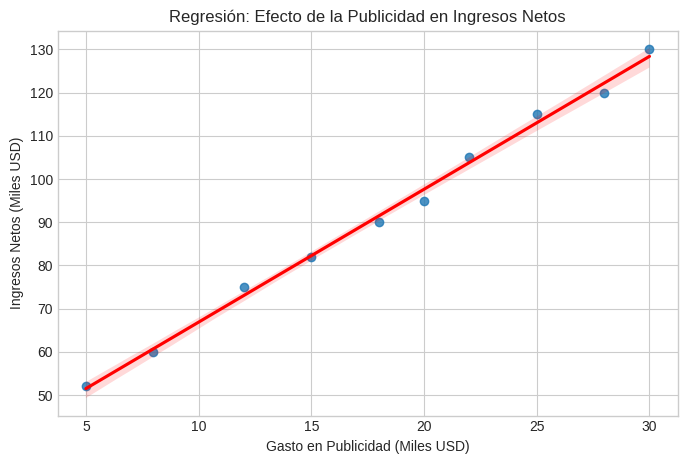

In [24]:
# Gráfica de dispersión y línea de tendencia empleando Seaborn
plt.figure(figsize=(8, 5))
sns.regplot(x=gasto_pub, y=ingresos, ci=95, line_kws={"color": "red"})
plt.title('Regresión: Efecto de la Publicidad en Ingresos Netos')
plt.xlabel('Gasto en Publicidad (Miles USD)')
plt.ylabel('Ingresos Netos (Miles USD)')
plt.show()

In [23]:
# Interpretar resultados y realizar la predicción para X = 25
gasto_nuevo = 25
prediccion_futura = modelo_ols.predict([1, gasto_nuevo])
prediccion_futura



array([113.00830538])

### Análisis Estratégico:
*Analiza el valor de $R^2$, define qué significa la pendiente en términos de ROI de publicidad, y concluye si el modelo es útil para la toma de decisiones presupuestales de la empresa.*
